# Outline
- In the last session we learned how to use optimize
- Now we re-write our SSE function to fit lines with slope and intercept
  - Not just horizontal lines
- How do we know if the line we fit is any good?
  - An amorphous cloud of points with no direction does not have a clear 'best fit' line.  Lines going in all directions fit about equally well.
  - A big cloud allows more lines than a cloud that has a clear direction
  - How do we know if the slope for our line is reliable?
- Answer:  A permutation test!!!
  - What do we mix up?
  - How do we do it?

# Python tools: 

## Conditional statements

One of the fundamental programming tools - you may have already discovered it...

```python
if ( [boolean expression ):
      do this if boolean expression is True
else:
      do this if boolean expression is False
```

Decision points in algorithms need 'if else' statements

- Note ':' after the boolean expression and after 'else'
- Note indenting
    - Indented section after 'if' is only run if boolean expression is True
    - Indented section after 'else' is only run if boolean expression is False

## Long conditional statements

Conditional statements can be longer, e.g.


In [ ]:
PostCodePrefix = "B"

if(PostCodePrefix == "B"):
    City = "Birmingham"
elif(PostCodePrefix == "EH"):
    City = "Edinburgh"
elif(PostCodePrefix == "YO"):
    City = "York"
else:
    City = "Don't know this place"
print("PostCode starts with: ",PostCodePrefix," City is: ",City)

- Notice that there is a boolean expression after both 'if' and 'elif'
- There is no boolean expression after 'else'

## Reminder - sorting data frames

Use the 'sort_values' method to sort a dataframe based on some column, e.g.:

```
my_df.sort_values("sort_column",ascending=False) # sort with highest value at the top
```

## \*\* USEFUL \*\*  Useful dataframe methods: value_counts

To get counts of how many times each value occurs in a column, use the 'value_counts' method.  E.g.

```
fire_country_counts = wildfire_incidents["country"].value_counts()
```

If the dataframe lists individual fire episodes and each episode has a country listed, the value_counts() method will tell you how many fires occurred in each country.

e.g.
| Fire name | Country | date |
|----------|------------|----------|
| Buongiorno | Italy | 15-8-2024 |
| Palisades | USA | 20-9-2024 |
| Champagne | France | 8-7-2024 |
| Lohansa County | USA | 11-7-2024 |
| Big swampy | USA | 28-9-2024 |
| Caffelatte | Italy | 25-7-2024 |
| Tramonte | Italy | 14-7-2024 |
| Acropolis | Greece | 13-6-2024|

This would produce 
| Country | count |
|---------|--------|
| Italy | 3 |
| USA | 2 |
| Greece | 1 |
| France | 1 |


## Useful dataframe methods:  dropna()

'dropna' will drop rows that have missing values in any position

```
no_missing_values_data = missing_values_data.dropna()
```


# Fitting lines - (not just horizontal lines)

### Reminder - formula for a line


The equation for a line is:
    
$$y = mx + b$$

Where:  
y = a value from you data that you want to predict  
x = a value from your data that you think predicts y (e.g. if ```y=weight``` ```x``` might be ```height```)  
m = the slope of the line relating x and y  (how many kilos does every cm of height add?)
b = the y intercept of the line -- where the line touches the y axis  

#### So we have _two_ values to change this time
- **The slope and the intercept**

Compare to the case for the mean -- we just had to optimize one value

### Exercise -- Write the code to fit the best line possible 
- any line, not just a horizontal line

#### Here are some points to use:

In [ ]:
line_to_fit = pd.read_csv("line_to_fit.csv")
plt.scatter(line_to_fit["x"],line_to_fit["y"])

#### Steps

- Write your error function - SSE for points on a line
  - Loop through all points and calculate an error value for each
    - Get the x value from the point
    - Get the y value from the same point
    - Use the slope and intercept for the line (pass these to the function)
      - Calculate the line's y-value using the point's x-value
      - Remember $line\_y\_value\ =\ intercept\ +\ (slope\ \times\ point\_x\_value)$
    - Calculate the squared distance between the line's y-value and the point's y-value
    - Store this value
  - Sum up the error values 


#### NOTE: Everything is the same as your previous SSE, _except_ you need to calculate the y value from the line, not just use the horizontal guess value

In [1]:
import numpy as np
import pandas as pd
import scipy.optimize as optimize
import matplotlib.pyplot as plt
# import seaborn as sns

In [ ]:
# Start of your SSE function
def sse(values_to_change,x_values,y_values):
# values_to_change are the slope and intercept values in an array, e.g.
#        [slope,intercept]
# YOU have to set the order of the values passed to sse.  
# Do you want [slope, intercept] or [intercept, slope]?
# Remember what you choose because the answer at the end will have
# values in the same order
#
# x_values are the x_values for the points
# y_values are the y_values for the points
#
# An example call to sse might be 
#       slope = 2
#       intercept = 3
#       sse_value = sse([slope,intercept], x_points, y_points)

# finish the function here


#### Once you have the SSE function written, use it with optimize minimize to get the best fit line

In [ ]:
# e.g.
x_values = line_to_fit["x"]
y_values = line_to_fit["y"]
result = optimize.minimize(sse,[1,5], args=(x_values,y_values))

#### The optimized values are in "x"

- 2.029 is the optimized value for the slope
- 7.843 is the optimized value for the intercept

Do these make sense?
- Does the line cross the y-axis at about 7.843?
  - Hard to see here because of the scale, but looks close to zero which is about right when the scale is big
- Does the line go up 2 y values for every x value (e.g. is [100,200] on the line)?
  - Yes - looks right

#### Practice

- The cell below has a routine that makes lines
  - You set the slope (see ```gen_slope```)
  - You set the intercept (see ```gen_intercept```)
  - You set a noise level -- Noisy lines will have points further from the line used to generate the data
  - You set the number of points to generate
  - The data end up in the file: ```line_to_fit2.csv```
- Practice fitting lines to data
  - Try noisy/less noisy data
  - Try more/fewer points
  - The slope and intercept of the fitted line won't match exactly the slope and intercept you set to generate the data
    - Remember that there is noise
    - Noise will change the fitted values
    - More noise = slope/intercept of fitted line may be further from the values used to generate the data
    - What about more/fewer points?

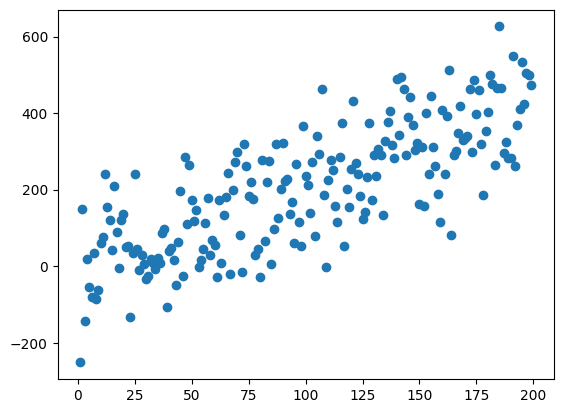

In [7]:
def make_a_noisy_line(slope,intercept,x_values,noise):
    y=np.zeros(len(x_values))
    noise = np.random.normal(0,noise,len(x_values))
    y = slope*x_values + intercept + noise
    return(y)

gen_slope = 2
gen_intercept = 10
noise = 100
number_of_values = 200
x_values = np.arange(1,number_of_values,1)
# reshape(-1,1) puts the values into a single column, rather than in an array
# LinearRegression below uses column values (because usually you'll be working with a column of a dataframe)
y_values = make_a_noisy_line(gen_slope,gen_intercept,x_values,noise).reshape(-1,1)

plt.scatter(x_values,y_values)

line_to_fit = pd.DataFrame()
line_to_fit["x"] = x_values
line_to_fit["y"] = y_values

line_to_fit.to_csv("line_to_fit2.csv")

## Permutation testing for regression

#### Example:  Cholesterol and hear disease (caution: These data are made up)

Text(0.5, 0, 'cholesterol')

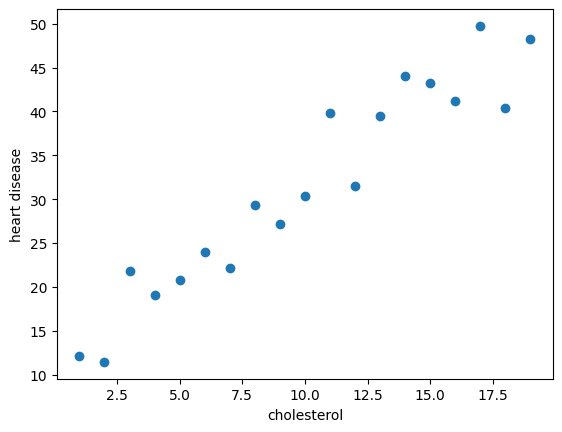

In [8]:
# make some data to fit

def make_a_noisy_line(slope,intercept,x_values,noise):
    y=np.zeros(len(x_values))
    noise = np.random.normal(0,noise,len(x_values))
    y = slope*x_values + intercept + noise
    return(y)

gen_slope = 2 # choose a slope for your line
gen_intercept = 10 # choose an intercept for your line

noise = 5 # scatter the points around the line
number_of_values = 20

x_values = np.arange(1,number_of_values,1)
# reshape(-1,1) puts the values into a single column, rather than in an array
# LinearRegression below uses column values (because usually you'll be working with a column of a dataframe)
y_values = make_a_noisy_line(gen_slope,gen_intercept,x_values,noise).reshape(-1,1)

line_to_fit = pd.DataFrame()
line_to_fit["x"] = x_values
line_to_fit["y"] = y_values

plt.scatter(line_to_fit["x"], line_to_fit["y"])
# let's call y 'heart disease'
plt.ylabel("heart disease")
# let's call x 'cholesterol'
plt.xlabel("cholesterol")

#### Permutation testing
- Remember we mix up the values to destroy differences/relationships and create a 'no difference' or 'no relationship' world.
- Then we test whether the real world is different from that
  - Hypothesis:  Cholesterol is related to the incidence of heart disease
  - Null hypothesis:  Cholesterol has nothing to do with heart disease - no relationship</p> <br>


#### What can we randomize (mix up/permute) to destroy any systematic relationship between cholesterol and heart disease?
- It might help to think about a situation where you have a measure that gets higher with time
- What can we mix up that would destroy that systematic increase?

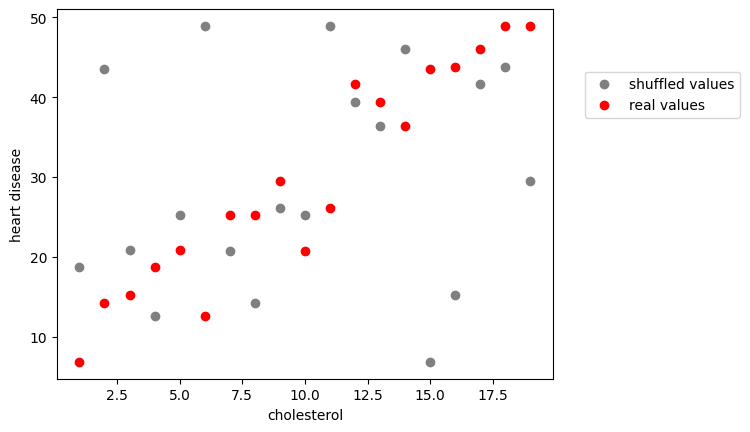

In [15]:
line_to_fit["shuffle_x"] = np.random.permutation(line_to_fit["x"]).copy()
plt.scatter(line_to_fit["shuffle_x"],line_to_fit["y"], color = "grey",label="shuffled values")
# shuffled values are in grey
plt.scatter(line_to_fit["x"],line_to_fit["y"], color="red",label="real values")
# actual values are in red

plt.xlabel("cholesterol")
plt.ylabel("heart disease")
plt.legend(bbox_to_anchor=(1.05, .85))
# bbox_to_anchor places the legend.
# 1,1 is the upper right corner of the plot
# 1.05 means 5% outside of the box in the x direction
# .85 means 85% of the height of the box in the y direction

# Shuffle the x-values.  These are your 'predictors' -- if you mix them up so they
# are no longer with the correct outcomes (e.g. now a low cholesterol value is with a high heart disease value)
# we will have destroyed the relationship between the two values

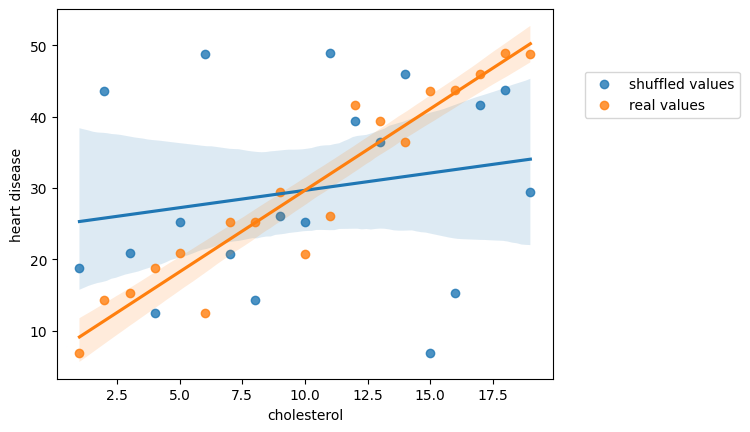

In [16]:
sns.regplot(data=line_to_fit,x="shuffle_x",y="y",label = "shuffled values")
sns.regplot(data=line_to_fit,x="x",y="y", label = "real values")

plt.xlabel("cholesterol")
plt.ylabel("heart disease")
plt.legend(bbox_to_anchor=(1.05, .85))

Text(0, 0.5, 'heart disease')

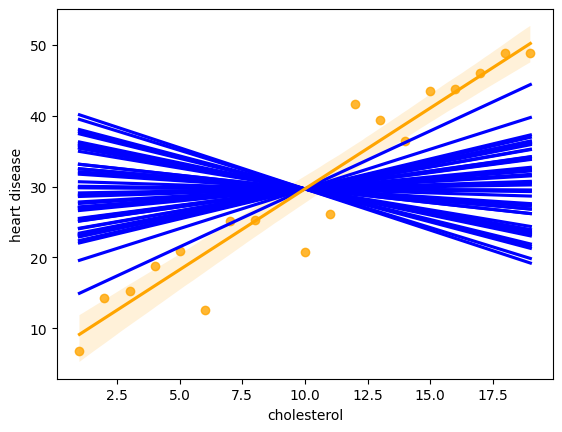

In [17]:
num_rand_lines = 50
for i in np.arange(0,num_rand_lines):
    line_to_fit["shuffle_x"] = np.random.permutation(line_to_fit["x"]).copy()
    sns.regplot(data=line_to_fit,x="shuffle_x",y="y",color="blue",scatter=False,ci=0)
sns.regplot(data=line_to_fit,x="x",y="y",color="orange",label="real values")

plt.xlabel("cholesterol")
plt.ylabel("heart disease")

### Exercise:  Adapt 'inside the loop' for a full simulation recipe and test whether the slope is different from 0
#### Plot the histogram with 'no relationship' slopes from the simulation and a line for the 'real world' slope
#### Calculate the probability of the 'real world' slope in the 'no relationship' world
- Hint:  Calculate the number of slope values from the 'no relationship world' that are >= 'real world' slope

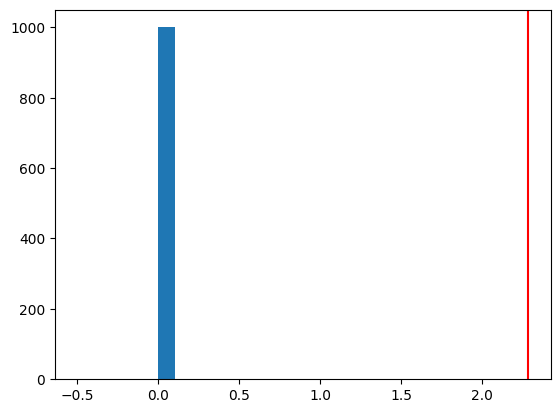

In [19]:
# we already have line_to_fit and real_slope from above.
# line_to_fit has columns for x, y and shuffle_x

# our usual 'recipe' for a loop
num_simulations = 1000
slope_values = np.zeros(num_simulations)
for i in np.arange(0,num_simulations):
    # do some stuff in the loop here, e.g. we will want to shuffle the x values
    line_to_fit["shuffle_x"] = np.random.permutation(line_to_fit["x"])
    

# plot the outcome
plt.hist(slope_values)
plt.axvline(real_slope, color="red")

# we haven't done anything yet, so the plot will just be a bar at zero